## **Machine Learning Aplicado a las Finanzas** 🚀
### **Sesión 2: Casos de ML en Finanzas**

Andrés C. Medina Sanhueza

Senior Datascientist Engineer 

anmedinas@gmail.com

## 🚦 **Introducción: Credit Scoring y el Problema de Default Bancario**

### 1.1 Contexto y Motivación

En el negocio de crédito, una institución financiera enfrenta diariamente la decisión de **otorgar o denegar** financiamiento a un solicitante. Esta decisión involucra evaluar la capacidad y voluntad de pago del cliente, es decir, cuantificar el riesgo de que el prestatario incumpla sus obligaciones contractuales, evento conocido como **default**.

El dataset `Bankloan.csv` utilizado en esta sesión representa este escenario: un conjunto de clientes bancarios caracterizados por variables socioeconómicas y financieras —edad, nivel educativo, años de empleo, ingresos, apalancamiento, deuda en tarjeta de crédito, otras deudas y carga mensual— con una etiqueta binaria `Default` que indica si el cliente cayó en incumplimiento (`1`) o no (`0`).

### 1.2 El Problema de Credit Scoring

El **credit scoring** es el proceso de asignar una puntuación numérica a cada solicitante que resume su perfil de riesgo crediticio. Formalmente, el objetivo es aprender una función:

\begin{equation*}
f: \mathbf{x}_i \mapsto s_i \in [0, 1]
\end{equation*}

donde $\mathbf{x}_i = (x_{i1}, \ldots, x_{ip})^{\top}$ es el vector de características del cliente $i$ y $s_i$ es su **score de riesgo**, interpretable como la probabilidad estimada de default.

En la práctica, este score se transforma en una decisión binaria mediante un umbral $\tau$:

\begin{equation*}
\hat{y}_i = \begin{cases} 1 & \text{si } s_i \geq \tau \quad \text{(rechazar solicitud)} \\ 0 & \text{si } s_i < \tau \quad \text{(aprobar solicitud)} \end{cases}
\end{equation*}

La elección de $\tau$ no es arbitraria: refleja un **trade-off** entre el costo de aprobar a un mal pagador (*falso negativo*) y el costo de rechazar a un buen pagador (*falso positivo*), balanceado por los objetivos comerciales y regulatorios de la institución.

### 1.3 Relevancia Regulatoria

Bajo los marcos de **Basilea II/III**, los bancos están obligados a estimar cuantitativamente su exposición al riesgo crediticio para determinar el capital regulatorio requerido. El credit scoring es el pilar central de este proceso, ya que alimenta directamente los modelos de **pérdida esperada** que veremos a continuación.

## 🎖️ **Pérdida Esperada y Estimación de la PD**

### 1.1  Marco de Pérdida Esperada (Expected Loss)

El estándar de la industria bancaria para cuantificar el riesgo crediticio de una cartera se basa en el concepto de **Pérdida Esperada** (*Expected Loss*, EL). Para una exposición crediticia individual $i$, la pérdida esperada se define como:

\begin{equation*}
\text{EL}_i = \text{PD}_i \times \text{LGD}_i \times \text{EAD}_i
\end{equation*}

donde cada componente tiene una interpretación económica precisa:

| Componente | Nombre | Definición |
|:---:|:---|:---|
| $\text{PD}_i$ | *Probability of Default* | Probabilidad de que el cliente $i$ incumpla dentro de un horizonte de tiempo $T$ |
| $\text{LGD}_i$ | *Loss Given Default* | Fracción de la exposición que se pierde dado que ocurre el default $\in [0,1]$ |
| $\text{EAD}_i$ | *Exposure at Default* | Monto total expuesto al momento del default (valor en USD) |

Para una cartera de $N$ créditos, la pérdida esperada agregada es:

\begin{equation*}
\text{EL}_{\text{cartera}} = \sum_{i=1}^{N} \text{PD}_i \times \text{LGD}_i \times \text{EAD}_i
\end{equation*}

<tr>
<td><img src="figs/ECL.png" align="middle" style="width: 1000px;"/> </td>
</tr>

### 1.2 Estimación de la PD mediante Credit Scoring

La componente que se modela, mediante modelos estadisticos y modelos de machine learning, es la $\text{PD}_i$. En el contexto de este dataset, la variable `Default` es la realización observada del evento de incumplimiento:

$$Y_i = \begin{cases} 1 & \text{si el cliente } i \text{ cayó en default} \\ 0 & \text{en caso contrario} \end{cases}$$

Bajo el supuesto de que $Y_i \sim \text{Bernoulli}(\pi_i)$, el objetivo es estimar:

\begin{equation*}
\widehat{\text{PD}}_i = \hat{\pi}_i = P(Y_i = 1 \mid \mathbf{x}_i)
\end{equation*}

#### 1.3 Modelo de Regresión Logística (baseline)

El modelo canónico para estimar la PD es la **regresión logística**, que parametriza la probabilidad mediante la función sigmoide:

\begin{equation*}
\hat{\pi}_i = \sigma(\boldsymbol{\beta}^{\top} \mathbf{x}_i) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_{i1} + \cdots + \beta_p x_{ip})}}
\end{equation*}

Los parámetros $\boldsymbol{\beta} \in \mathbb{R}^{p+1}$ se estiman maximizando la **log-verosimilitud** del modelo Bernoulli:

\begin{equation*}
\hat{\boldsymbol{\beta}} = \underset{\boldsymbol{\beta}}{\arg\max} \sum_{i=1}^{N} \left[ y_i \log \hat{\pi}_i + (1 - y_i) \log(1 - \hat{\pi}_i) \right]
\end{equation*}

Esta función objetivo es equivalente a minimizar la **entropía cruzada binaria** (*binary cross-entropy loss*), que es el criterio de entrenamiento estándar para todos los clasificadores probabilísticos que utilizaremos en esta sesión (Logistic Regression, Random Forest, XGBoost, MLP).

#### 1.4 Conexión con el Score y el Odds Ratio

En credit scoring, la salida del modelo se suele expresar como el **log-odds** o *logit*:

\begin{equation*}
\text{logit}(\hat{\pi}_i) = \log \frac{\hat{\pi}_i}{1 - \hat{\pi}_i} = \boldsymbol{\beta}^{\top} \mathbf{x}_i
\end{equation*}

Esta cantidad es el **score lineal** del cliente $i$. Una transformación lineal de este score genera el **scorecard** (escala de puntos), donde mayor puntaje indica **menor riesgo**:

\begin{equation*}
\text{Score}_i = A - B \cdot \boldsymbol{\beta}^{\top} \mathbf{x}_i
\end{equation*}

con $A$ y $B$ constantes de calibración definidas por la institución financiera.

### 1.5 Variables del Dataset y su Rol en la PD

En el dataset `Bankloan.csv`, las variables predictoras $\mathbf{x}_i$ que alimentan la estimación de la PD son:

- **Capacidad de pago**: `Income` (ingresos), `MonthlyLoad` (carga mensual de deuda sobre ingreso)
- **Nivel de endeudamiento**: `Leverage` (deuda/ingreso), `Creddebt` (deuda en tarjeta), `OthDebt` (otras deudas)
- **Estabilidad del cliente**: `Employ` (antigüedad laboral), `Address` (estabilidad domiciliaria)
- **Perfil sociodemográfico**: `Age` (edad), `Education` (nivel educativo)

El objetivo de la clase, es construir modelos $f(\mathbf{x}_i)$ que estimen $\widehat{\text{PD}}_i$ con la mayor precisión posible, evaluando su desempeño con métricas como el **AUROC**, el **KS statistic** y el **Gini coefficient**, estándares de la industria crediticia para medir el poder discriminante de un scorecard.

📌 **`Nota`**: Algunas librerías adicionales para correr este notebook, son:

```bash 
! pip install ydata-profiling
! pip install scorecardpy
! pip install optbinning
! pip install xgboost 
! pip install pyod
```

## 🪁 Modelamiento
### **1. Lectura de datos**

* `Customer:` ID, o etiqueta única, del prestatario (NO predictivo).
* `Age:` Edad del prestatario en años.
* `Education:` nivel de educación máximo que alcanzó el prestatario. 1: Primaria completa. 2: Secundaria completa. 3: Ed. Superior incompleta. 4: Educación superior completa. 5: Con estudios de posgrado (maestría completa o doctorado).
* `Employ:` Años en el trabajo actual.
* `Address:` Años en la dirección actual.
* `Income:` Ingresos en miles de USD.
* `Leverage:` Relación deuda / ingresos.
* `CredDebt:` Deuda permanente de la tarjeta de crédito.
* `OthDebt:` Otra deuda en miles de USD.
* `MonthlyLoad:` porcentaje mensual del salario utilizado para pagar deudas.
* `Default`: 1 Si el cliente es default, 0 en otro caso.

Las librerías necesarias para el desarrollo del modelo son:

```python
import sys
!{sys.executable} -m pip install "setuptools<80"
```

In [1]:
%matplotlib inline

# Transformaciones y Pipelines
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from scipy.stats import zscore

# Modulos de Modelamiento 
from pyod.models.knn import KNN
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier, plot_importance

# Modulo de Metricas
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

# Modulos de Visualizaciones y procesamiento
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt 
from data_profiling import ProfileReport
import pandas as pd
import pkg_resources
import seaborn as sns
import numpy as np
import pickle
import os

# Modulo de Scorecard 
import scorecardpy as sc

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_style('dark')

Para cargar el set de datos que se encuentran en formato `csv`, utilizaremos el módulo `read_csv()` de la librería `pandas` como se muestra a continuación.

In [2]:
bankloan_data = pd.read_csv("data_raw/Bankloan.csv", sep=",")

Si bien, la librería `pandas` cuenta con una función que genera una resumen estadístico de los datos, en ocasiones, esta función no es las más adecuada debido a que no presenta ausencia de datos (missings, NaN u otro). Por otro lado, el despliegue de la función `describe()` visualmente no entrega información mas detallada. Para obtener un reporte de analisis descriptivo completo de los datos, utilizaremos la liberia `ProfileReport`.

In [3]:
profile = ProfileReport(bankloan_data, title="Pandas Profiling Report Bankloan")

In [4]:
profile.to_file("Pandas_Profiling_Report_Bankloan.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:00<00:00, 38193.17it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Para chequear el reporte generado, hay que revisar en el directorio actual donde tenemos corriendo jupyter si se encuentra el archivo `Pandas_Profiling_Report_Bankloan.html`. En caso de linux, se puede navegar el directorio actual mediante la sintáxis `ls -l`

In [5]:
! ls -l 

total 17616
-rw-r--r--@ 1 anmedinas  staff   144751 Apr 23 12:46 BankloanCleanNewVars.pkl
-rwxr-xr-x@ 1 anmedinas  staff  2197280 Apr 23 02:01 MLCreditScoring.html
-rwxr-xr-x@ 1 anmedinas  staff  1111247 Apr 23 13:00 MLCreditScoring.ipynb
-rw-r--r--@ 1 anmedinas  staff  5418735 Apr 23 13:00 Pandas_Profiling_Report_Bankloan.html
-rw-r--r--@ 1 anmedinas  staff   132916 Apr 23 12:40 Procesamiento_Bankloan_data_20211230.pkl
drwxr-xr-x@ 4 anmedinas  staff      128 Apr 23 12:46 data_process
drwxr-xr-x@ 3 anmedinas  staff       96 Apr 23 11:18 data_raw
drwxr-xr-x@ 3 anmedinas  staff       96 Apr 23 11:18 figs


---

### **2. Preprocesamiento** 

#### **2.1. Inspección de datos** 

El propósito de esta sección es tomar líneas de acción en los casos donde se presentan datos faltantes o missings y outliers.  En primera instancia, revisemos cuáles son las variables que presentan datos faltantes.

In [6]:
bankloan_data.isnull().any()

customer       False
Age            False
Education      False
Employ         False
Address         True
Income          True
Leverage        True
Creddebt        True
OthDebt         True
MonthlyLoad    False
Default        False
dtype: bool

De acuerdo a la instrucción anterior, se tienen cuatro variables con datos faltantes (condición lógica `True`). Para cuantificar la cantidad de datos faltantes por variable, generaremos la siguiente instrucción que retornará la suma de datos faltantes por variables o columnas del set de datos.

In [7]:
null_columns = bankloan_data.columns[bankloan_data.isnull().any()]
bankloan_data[null_columns].isnull().sum()

Address      1
Income       1
Leverage     1
Creddebt     1
OthDebt     11
dtype: int64

En la variable `null_columns` se almacenan las variables que contienen datos faltantes y en la siguiente instrucción se acceden a estas columnas y se suman los registros que son 
`null`, de esta forma, podemos ver que la variable que tienen mayor cantidad de registros faltantes es `OthDebt`. Para ver cuales son los registros que aparecen con NaN, ejecutemos la siguiente instrucción.

In [8]:
bankloan_data.loc[bankloan_data.isnull().any(axis = 1), :]

,customer,Age,Education,Employ,Address,Income,Leverage,Creddebt,OthDebt,MonthlyLoad,Default
17,10423,19,Bas,2,0.0,31.0,0.3,0.02,NaN,0.01,1
247,71896,20,SupInc,0,0.0,21.0,1.3,0.18,NaN,0.07,1
255,72327,19,Med,0,NaN,NaN,NaN,NaN,NaN,0.01,1
293,74471,39,Bas,8,9.0,41.0,0.1,0.03,NaN,0.00,0
587,244023,31,SupCom,1,7.0,69.0,0.4,0.19,NaN,0.01,0
745,315892,22,SupInc,0,1.0,14.0,2.5,0.26,NaN,0.20,0
748,315948,41,Med,21,9.0,64.0,0.3,0.12,NaN,0.01,0
817,335635,18,Med,0,0.0,24.0,0.9,0.13,NaN,0.05,1
1194,372485,20,SupInc,0,0.0,13.0,1.1,0.05,NaN,0.10,0
1254,376801,23,SupCom,0,2.0,19.0,1.4,0.18,NaN,0.09,0


Al momento de implementar métodos de imputación de datos, se deben considerar la cantidad de registros que contienen `NaN`, qué tipo de variables son las que contienen `NaN`. En los casos que tenemos pocos registros, podemos imputar por alguna medida de tendencia central como la media, la moda o la mediana, sin embargo, la naturaleza de éstas variables son de forma asimétrica por lo que se aconseja imputar por la mediana. Por otro lado, el registro `999999` de la variable `Leverage` la podemos imputar como `NaN`.

In [9]:
# Reemplazo el Valor 999999 por NaN.
bankloan_data.Leverage.values[bankloan_data.Leverage.values == 999999] = np.nan

In [10]:
bankloan_data.head()

,customer,Age,Education,Employ,Address,Income,Leverage,Creddebt,OthDebt,MonthlyLoad,Default
0,10012,28,Med,7,2.0,44.0,17.7,2.99,4.80,0.58,0
1,10017,64,Posg,34,17.0,116.0,14.7,5.05,12.00,0.27,0
2,10030,40,Bas,20,12.0,61.0,4.8,1.04,1.89,0.13,0
3,10039,30,Bas,11,3.0,27.0,34.5,1.75,7.56,1.62,0
4,10069,25,Bas,2,2.0,30.0,22.4,0.76,5.96,0.97,1


In [11]:
# Relleno los NaN con la mediana de los datos.
bankloan_data.fillna(bankloan_data.median(numeric_only=True), inplace=True)

In [12]:
# Resumen descrpiptivo de los datos 
bankloan_data.describe()

,customer,Age,Employ,Address,Income,Leverage,Creddebt,OthDebt,MonthlyLoad,Default
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,257714.548000,34.174000,6.952000,6.308667,59.602000,9.940600,1.935567,3.860287,0.365447,0.365333
std,139555.147719,13.142306,8.977644,6.045640,67.124278,6.662313,2.973593,5.325332,0.293937,0.481684
min,10012.000000,18.000000,0.000000,0.000000,12.000000,0.100000,0.000000,0.100000,0.000000,0.000000
25%,98638.750000,24.000000,0.000000,2.000000,27.000000,4.800000,0.420000,1.137500,0.150000,0.000000
50%,315991.500000,31.000000,4.000000,5.000000,40.000000,8.500000,0.990000,2.240000,0.290000,0.000000
75%,370701.500000,42.000000,10.000000,9.000000,64.000000,13.525000,2.200000,4.572500,0.500000,1.000000
max,453777.000000,79.000000,63.000000,34.000000,1079.000000,40.700000,35.970000,63.470000,2.150000,1.000000


#### **2.2. Limpieza de datos** 

Para verificar la existencia de datos outliers en el conjunto de datos, visualizaremos los datos mediante histogramas, en partcular variables de naturaleza continua.

In [13]:
bankloan_data.columns

Index(['customer', 'Age', 'Education', 'Employ', 'Address', 'Income',
       'Leverage', 'Creddebt', 'OthDebt', 'MonthlyLoad', 'Default'],
      dtype='object')

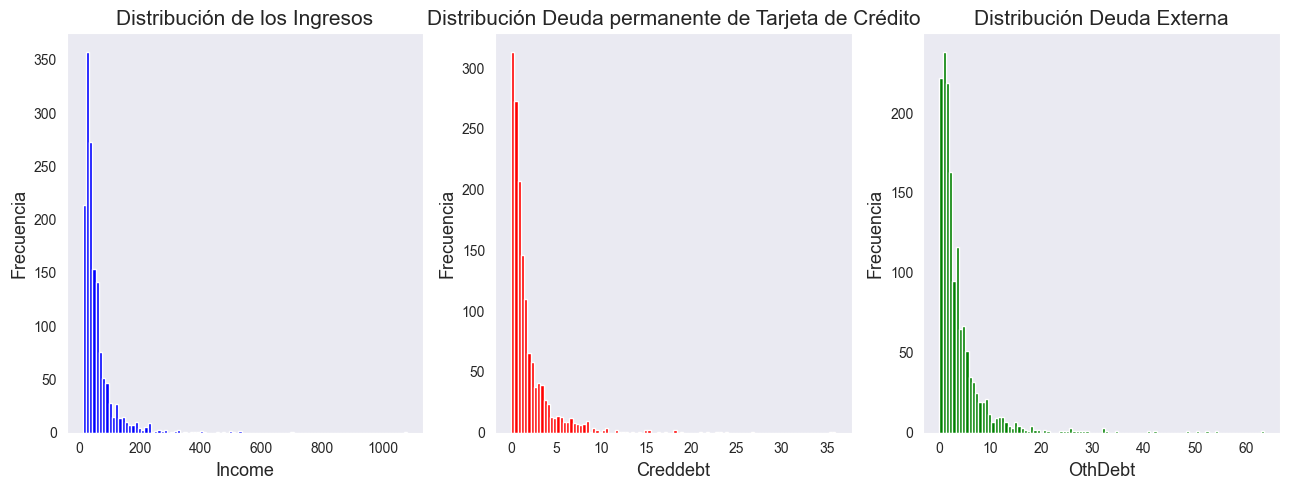

In [14]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13,5))

ax1.hist(bankloan_data.Income, bins=100, color = "blue", ec="blue")
ax1.set_xlabel("Income", fontsize = 13)
ax1.set_ylabel("Frecuencia", fontsize = 13)
ax1.set_title(r"Distribución de los Ingresos", fontsize=15)

ax2.hist(bankloan_data.Creddebt, bins=100, color = "red", ec="red")
ax2.set_xlabel("Creddebt", fontsize = 13)
ax2.set_ylabel("Frecuencia", fontsize = 13)
ax2.set_title(r"Distribución Deuda permanente de Tarjeta de Crédito", fontsize=15)

ax3.hist(bankloan_data.OthDebt, bins=100, color = "green", ec="green")
ax3.set_xlabel("OthDebt", fontsize = 13)
ax3.set_ylabel("Frecuencia", fontsize = 13)
ax3.set_title(r"Distribución Deuda Externa", fontsize=15)
plt.tight_layout()

plt.show()

Claramente, estas variables exhiben observaciones atípicas. Para poder tratar este tipo de datos, existen una amplia gama de metodologías que nos permite tratar este problema, partiendo de los clásicos boxplots hasta algoritmos de machine learning (`DBscan()`, `HDBscan()`, `KNN()`, `SVC()`, etc). Para este ejemplo, ilustremos como sería aplicar `KNN()` a este conjunto de variables que exhiben outliers y si el resultado es consistente. Para esta tarea, utilizaremos la librería `pyod` y el parámetro que utiliza `KNN()` en este contexto, es `contamination` que es una tasa aproximada del porcentaje de datos atípicos que existen en los datos.  

In [15]:
X   = bankloan_data[['Income','Creddebt', 'OthDebt']]
clf = KNN(contamination = 0.10, metric = "manhattan") 
clf.fit(X)
y_pred = clf.predict(X)
outliers_df = X[y_pred == 1]
outliers_df

,Income,Creddebt,OthDebt
1,116.0,5.05,12.00
12,124.0,9.52,14.16
23,103.0,10.41,3.29
37,259.0,1.55,17.10
40,150.0,0.73,14.12
...,...,...,...
1435,526.0,5.47,8.21
1451,198.0,8.10,5.56
1461,533.0,1.86,2.40
1472,186.0,7.46,13.56


In [16]:
outliers_df.shape

(135, 3)

De acuerdo al resultado, podemos ver que el algoritmo detectó 135 registros que son outliers. Sin embargo, si comparamos los resultados con el histograma, vemos que existe una inconsistencia. Para validarlo, revisemos un resumen descriptivo rápido.

In [17]:
outliers_df.describe()

,Income,Creddebt,OthDebt
count,135.000000,135.000000,135.000000
mean,208.703704,7.429111,14.501926
std,137.201077,6.520633,11.519919
min,42.000000,0.250000,1.060000
25%,124.500000,3.210000,7.035000
50%,175.000000,5.590000,12.470000
75%,235.000000,8.920000,17.795000
max,1079.000000,35.970000,63.470000


Como se puede apreciar, la aplicación de algoritmos de machine learning para la detección de outliers en variables que no provienen de un proceso generativo normal, no funciona (variables tipo exponencial). Si bien existen formas sofisticadas para detectar outliers en distribuciones con asimetrías, para efectos de este laboratorio, nos basaremos en aspectos visuales. Consideraremos como outlier en la variable `income` valores por sobre 300, para la variable `Creddebt` valores por sobre 15 y para la variable `OthDebt` valores por sobre 30. 

In [18]:
bankloan_data = bankloan_data.loc[(bankloan_data['Income'] < 300) & (bankloan_data['Creddebt'] < 15) & (bankloan_data['OthDebt'] < 30)]

Visualización del boxplot del nuevo conjunto de datos.

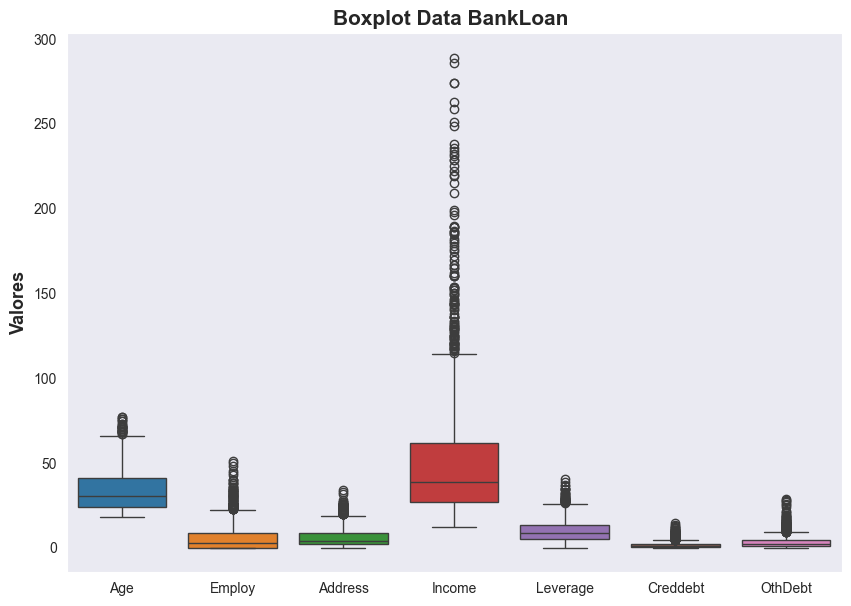

In [19]:
fig, ax = plt.subplots(figsize=(10,7))
a = sns.boxplot(x='variable', 
                y='value',
                hue='variable',
                data = pd.melt(bankloan_data.iloc[:, np.r_[1,3:9]]), ax=ax)
a.set_xlabel("", fontsize=13,fontweight='bold')
a.set_ylabel("Valores", fontsize=13,fontweight='bold')
a.set_title("Boxplot Data BankLoan ", fontsize=15,fontweight='bold')
plt.show()

Para este efecto, guardaremos el conjunto de datos ya limpios. Si bien, los datos se pueden guardar en diferentes extensiones, es recomendable guardarlos como objetos.

In [20]:
pd.to_pickle(bankloan_data, 'Procesamiento_Bankloan_data_20211230.pkl')

#### **2.3. Estandarización y Codificación de datos** 

Para estandarizar las variables numéricas y codificar las variables cualitativas, revisemos cual es la naturaleza de las variables.

In [21]:
bankloan_data = pd.read_pickle('Procesamiento_Bankloan_data_20211230.pkl')

In [22]:
bankloan_data.head(5)

,customer,Age,Education,Employ,Address,Income,Leverage,Creddebt,OthDebt,MonthlyLoad,Default
0,10012,28,Med,7,2.0,44.0,17.7,2.99,4.80,0.58,0
1,10017,64,Posg,34,17.0,116.0,14.7,5.05,12.00,0.27,0
2,10030,40,Bas,20,12.0,61.0,4.8,1.04,1.89,0.13,0
3,10039,30,Bas,11,3.0,27.0,34.5,1.75,7.56,1.62,0
4,10069,25,Bas,2,2.0,30.0,22.4,0.76,5.96,0.97,1


In [23]:
bankloan_data.select_dtypes(include=['object']).columns.tolist()

['Education']

A pesar que la variable `Education` es una variable numérica, en realidad representa a categorias de variables (variable ordinales) por lo tanto, no se puede tratar como las variables antes normalizadas. Independiente si las variables son cualitativas ordinales o nominales, éstas se deben codificar como variables dummies. A esta codificación se suele llama `OneHotEncoding()`.

In [24]:
bankloan_data.select_dtypes(exclude=['object']).columns.tolist()

['customer',
 'Age',
 'Employ',
 'Address',
 'Income',
 'Leverage',
 'Creddebt',
 'OthDebt',
 'MonthlyLoad',
 'Default']

Para hacer un tratamiento más al detalle, utilizaremos escalamiento para variables cuantitativas (`MinMaxScaler()`,`StandarScaler()`,`RobustScaler()`) y para variables cualitativas haremos codificación `OneHotEncoder()`. Para aplicar estas transformaciones, se recomienda el usos de `Pipeline` y `ColumnTransformer`. Definamos el conjunto de variables a tratar:

In [25]:
numeric_features = [
    'Age', 'Employ', 'Address', 'Income',
    'Leverage','Creddebt','OthDebt','MonthlyLoad']

categorial_features = ['Education']

La siguiente instruccion genera un pipeline que escala las variables cuantitativas mediante `StandarScaler()` y codifica las cualitativas con `OneHotEncoder()`.

In [26]:
numeric_transformer     = Pipeline(steps = [("scaler", StandardScaler())])
categorical_transformer = OneHotEncoder(handle_unknown = "ignore")

preprocessor = ColumnTransformer(
    transformers = [
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorial_features),
    ], 
)

In [27]:
from sklearn import set_config
set_config(display="diagram")
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

#### **2.4. Entrenamiento de Modelos** 

En este proceso, se proporcionarán datos de entrenamiento de los cuales los modelos basados en aprendizaje, aprenden ciertos patrones o comportamientos que caracterizan a los clientes que caen en default. Por otro lado, la gran parte de los modelos basados en machine learning, cuentan con más de un hiperparámetro, por lo que es necesario ajustar los valores de ellos en relación a el conjunto de datos de los cuales debe aprender. En ese sentido, en la literatura existen tres formas de entrenar estos hiperparámetros.

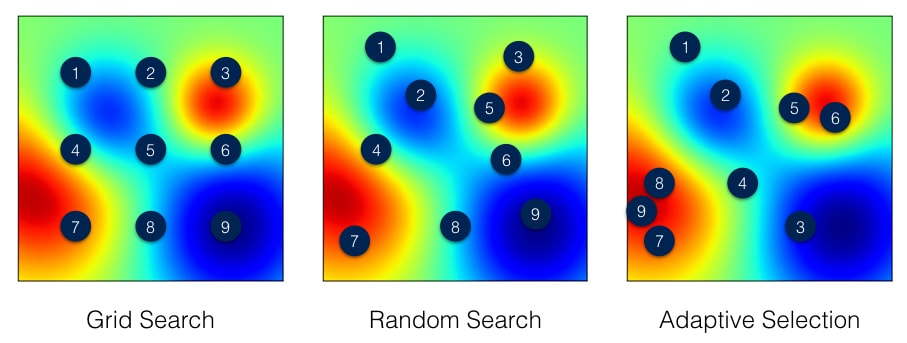

In [28]:
from IPython.display import Image
Image('figs/gridsearch.jpeg')

Ante cualquier proyecto de modelamiento predictivo, es necesario generar una partición de datos en `training` y `testing`. Los porcentajes, son relativos, pero bordean entre los 70-30 u 80-20. La garantía de generar este proceso previo al entrenamiento de un modelo de clasificación o predicción, es que el modelo encontrado, tenga problemas de sobreajuste u `overfitting`. Este fenómeno es muy común cuando no se hace un proceso de partición previa y el modelo entrenado con toda la muestra, no aprende ante datos fuera de la muestra, por lo tanto, este tipo de modelos con sobreajuste tiene rendimientos deficientes.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(bankloan_data.drop(columns=['customer','Default']), 
                                                    bankloan_data['Default'], 
                                                    test_size=.2, 
                                                    random_state=1234)

---
##### **2.4.1 Pipeline para Support Vector Machine**

In [30]:
# Silencia warnings de njobs = -1 
os.environ["PYTHONWARNINGS"] = "ignore"   
warnings.filterwarnings("ignore")

clf_01 = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("SVM", SVC())   
    ])

parameters = {'SVM__C':[1, 10, 100],
             'SVM__gamma':[0.1, 0.01],
             'SVM__kernel':['rbf','linear']}

grid_pipeline = GridSearchCV(clf_01, param_grid = parameters, 
                             cv=10, n_jobs = -1, scoring = 'roc_auc')


grid_pipeline.fit(X_train, y_train)
y_pred = grid_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.81      0.79       183
           1       0.66      0.59      0.63       111

    accuracy                           0.73       294
   macro avg       0.71      0.70      0.71       294
weighted avg       0.73      0.73      0.73       294



In [31]:
print("Parametros mejor tuneados: {}".format(grid_pipeline.best_params_))

Parametros mejor tuneados: {'SVM__C': 1, 'SVM__gamma': 0.1, 'SVM__kernel': 'linear'}


In [32]:
print("Mejor AUCRoC: {}".format(grid_pipeline.best_score_))

Mejor AUCRoC: 0.8370668143226283


---
##### **2.4.2 Pipeline para Random Forest**

In [33]:
# Silencia warnings de njobs = -1 
os.environ["PYTHONWARNINGS"] = "ignore"   
warnings.filterwarnings("ignore")

clf_02 = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("RF", RandomForestClassifier(random_state = 123))   
    ])

parameters = {
    "RF__n_estimators": [100, 500, 1000],
    "RF__max_depth": [1, 5, 10, 25],
    "RF__max_features": [*np.arange(0.1, 1.1, 0.1)],
}

grid_pipeline = GridSearchCV(clf_02, param_grid = parameters, cv=10, n_jobs=-1, 
                             scoring='roc_auc')


grid_pipeline.fit(X_train, y_train)
y_pred = grid_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.79      0.78       183
           1       0.65      0.64      0.64       111

    accuracy                           0.73       294
   macro avg       0.71      0.71      0.71       294
weighted avg       0.73      0.73      0.73       294



In [34]:
print("Parametros mejor tuneados: {}".format(grid_pipeline.best_params_))

Parametros mejor tuneados: {'RF__max_depth': 5, 'RF__max_features': np.float64(0.4), 'RF__n_estimators': 100}


In [35]:
print("Mejor AUCRoC: {}".format(grid_pipeline.best_score_))

Mejor AUCRoC: 0.8209176818014026


##### **2.4.3 Pipeline para Decision Tree**

In [36]:
# Silencia warnings de njobs = -1 
os.environ["PYTHONWARNINGS"] = "ignore"   
warnings.filterwarnings("ignore")

clf_03 = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("DT", DecisionTreeClassifier(random_state = 123))   
    ])

parameters = {
    "DT__criterion": ['gini','entropy'],
    "DT__max_depth": [5, 6, 7, 8, 9],
    "DT__max_features": ['auto', 'sqrt', 'log2'],
}

grid_pipeline = GridSearchCV(clf_03, param_grid = parameters, cv=10, 
                             scoring='roc_auc', n_jobs=-1)
grid_pipeline.fit(X_train, y_train)
y_pred = grid_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.80      0.77       183
           1       0.63      0.56      0.59       111

    accuracy                           0.71       294
   macro avg       0.69      0.68      0.68       294
weighted avg       0.70      0.71      0.70       294



In [37]:
print("Parametros mejor tuneados: {}".format(grid_pipeline.best_params_))

Parametros mejor tuneados: {'DT__criterion': 'entropy', 'DT__max_depth': 5, 'DT__max_features': 'sqrt'}


In [38]:
print("Mejor AUCRoC: {}".format(grid_pipeline.best_score_))

Mejor AUCRoC: 0.7572078257659653


---
##### **2.4.4 Pipeline para KNN**

In [39]:
# Silencia warnings de njobs = -1 
os.environ["PYTHONWARNINGS"] = "ignore"   
warnings.filterwarnings("ignore")

clf_04 = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("KNN",KNeighborsClassifier())   
    ])

parameters = {'KNN__n_neighbors': [3, 5, 7, 9, 11]}
grid_pipeline = GridSearchCV(clf_04, param_grid = parameters, cv=10,
                             scoring='roc_auc', n_jobs=-1)
grid_pipeline.fit(X_train, y_train)
y_pred = grid_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.80      0.79       183
           1       0.65      0.60      0.63       111

    accuracy                           0.73       294
   macro avg       0.71      0.70      0.71       294
weighted avg       0.72      0.73      0.73       294



In [40]:
print("Parametros mejor tuneados: {}".format(grid_pipeline.best_params_))

Parametros mejor tuneados: {'KNN__n_neighbors': 11}


In [41]:
print("Mejor AUCRoC: {}".format(grid_pipeline.best_score_))

Mejor AUCRoC: 0.7961328903654484


---
##### **2.4.5 Pipeline para Regresión Logística**

In [42]:
# Silencia warnings de njobs = -1 
os.environ["PYTHONWARNINGS"] = "ignore"   
warnings.filterwarnings("ignore")

clf_05 = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("LR",LogisticRegression(random_state=1234,  solver='liblinear', max_iter=1000))   
    ])

parameters = {
    'LR__C': np.logspace(-3,3,7),
    'LR__penalty': ["l1","l2"]}

grid_pipeline = GridSearchCV(clf_05, param_grid = parameters, cv=10, 
                             scoring='roc_auc', n_jobs=-1)
grid_pipeline.fit(X_train, y_train)
y_pred = grid_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.81      0.80       183
           1       0.67      0.62      0.64       111

    accuracy                           0.74       294
   macro avg       0.73      0.72      0.72       294
weighted avg       0.74      0.74      0.74       294



In [43]:
print("Parametros mejor tuneados: {}".format(grid_pipeline.best_params_))

Parametros mejor tuneados: {'LR__C': np.float64(0.1), 'LR__penalty': 'l1'}


In [44]:
print("Mejor AUCRoC: {}".format(grid_pipeline.best_score_))

Mejor AUCRoC: 0.8406703580657068


---
##### **2.4.6 Pipeline para Perceptrón Multicapa**

In [45]:
# Silencia warnings de njobs = -1 
os.environ["PYTHONWARNINGS"] = "ignore"   
warnings.filterwarnings("ignore")

clf_06 = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("MLP", MLPClassifier(random_state=1234, max_iter=300))   
    ])

parameters = {
    'MLP__hidden_layer_sizes': [(50,50,50), (50,100,50), (100,)],
    'MLP__activation': ['tanh', 'relu'],
    'MLP__solver': ['sgd', 'adam'],
    'MLP__alpha': [0.0001, 0.05],
    'MLP__learning_rate': ['constant','adaptive']}

grid_pipeline = GridSearchCV(clf_06, param_grid = parameters, cv=10, 
                             scoring='roc_auc', n_jobs=-1)

grid_pipeline.fit(X_train, y_train)
y_pred = grid_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.81      0.80       183
           1       0.68      0.66      0.67       111

    accuracy                           0.75       294
   macro avg       0.74      0.73      0.73       294
weighted avg       0.75      0.75      0.75       294



In [46]:
print("Parametros mejor tuneados: {}".format(grid_pipeline.best_params_))

Parametros mejor tuneados: {'MLP__activation': 'tanh', 'MLP__alpha': 0.05, 'MLP__hidden_layer_sizes': (100,), 'MLP__learning_rate': 'constant', 'MLP__solver': 'adam'}


In [47]:
print("Mejor AUCRoC: {}".format(grid_pipeline.best_score_))

Mejor AUCRoC: 0.8370299003322259


---
##### **2.4.7 Pipeline para Xtreme Gradient Boosting**

In [48]:
# Silencia warnings de njobs = -1 
os.environ["PYTHONWARNINGS"] = "ignore"   
warnings.filterwarnings("ignore")

clf_07 = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("XGB", XGBClassifier(random_state=1234))   
    ])

parameters = {
    'XGB__learning_rate': [0.01, 0.1],
    'XGB__max_depth': [3,5,7,10],
    'XGB__min_child_weigth': [1,3,5],
    'XGB__subsample': [0.5, 0.7],
    'XGB__colsample_bytree': [0.5, 0.7],
    'XGB__n_estimators': [100, 200, 500],
    'XGB__objective': ['binary:logistic']}

grid_pipeline = GridSearchCV(clf_07, param_grid = parameters, cv=10, 
                             scoring='roc_auc', n_jobs=-1)

grid_pipeline.fit(X_train, y_train)
y_pred = grid_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.79      0.79       183
           1       0.66      0.66      0.66       111

    accuracy                           0.74       294
   macro avg       0.73      0.73      0.73       294
weighted avg       0.74      0.74      0.74       294



In [49]:
print("Parametros mejor tuneados: {}".format(grid_pipeline.best_params_))

Parametros mejor tuneados: {'XGB__colsample_bytree': 0.7, 'XGB__learning_rate': 0.01, 'XGB__max_depth': 3, 'XGB__min_child_weigth': 1, 'XGB__n_estimators': 500, 'XGB__objective': 'binary:logistic', 'XGB__subsample': 0.7}


In [50]:
print("Mejor AUCRoC: {}".format(grid_pipeline.best_score_))

Mejor AUCRoC: 0.8248903654485049


---

### **3. Transformación Weight of Evidence (WOE)**

Hasta este paso, ya tenemos un tablón limpio y preparado para construir un scorecard, sin embargo siempre está la posibilidad de crear variables nuevas a partir de las ya existentes. Por ejemplo, podríamos crear la variable `OthDebtRatio` que consiste en el ratio de deuda externa del cliente representada por `OthDebt` y los ingresos del cliente `Income`.

In [51]:
bankloan_data = pd.read_pickle('Procesamiento_Bankloan_data_20211230.pkl')
bankloan_data['OthDebtRatio'] = bankloan_data['OthDebt'] / bankloan_data['Income']

In [52]:
bankloan_data.columns

Index(['customer', 'Age', 'Education', 'Employ', 'Address', 'Income',
       'Leverage', 'Creddebt', 'OthDebt', 'MonthlyLoad', 'Default',
       'OthDebtRatio'],
      dtype='object')

Como calcular WoE significa que debemos usar la variable objetivo (`Default`), primero debemos crear un conjunto de entrenamiento y validación. Si bien `scikit` tiene un módulo de partición de datos, para este efecto, utilizaremos el módulo `split_df` de la librería `scorecardpy`. Generemos la respectiva partición del conjunto de datos en `trainig` de un 70% y `test` con 30%. 

In [53]:
train, test = sc.split_df(bankloan_data.drop(columns=['customer']), 
                          y = 'Default',
                          ratio = 0.7, 
                          seed = 20211203).values()

#### **3.1. Construyendo los Binning**

La idea de esta transformación es que mediante ella, podamos descubrir cuál de las variables tiene un poder predictivo alto, medio y bajo a través del `Information Value (IV)`. Para poder calcular este estadístico, primero debemos calcular el `WOE` de cada variable.

In [54]:
# Silencia warnings de njobs = -1 
os.environ["PYTHONWARNINGS"] = "ignore"   
warnings.filterwarnings("ignore")

bins = sc.woebin(train, y = 'Default', 
                 min_perc_fine_bin = 0.05,    # Cuantos bins cortar inicialmente
                 min_perc_coarse_bin = 0.05,  # Porcentaje minimo por bins
                 stop_limit = 0.1,            # Valor minimo del Information Value 
                 max_num_bin = 8,             # Numero maximo de bins
                 method = 'tree')

[INFO] creating woe binning ...


Para visualizar los cortes por bins de cada variable, se puede acceder a ellos mediante la función `woebin_plot()`

{'Education': <Figure size 640x480 with 2 Axes>,
 'Age': <Figure size 640x480 with 2 Axes>,
 'Leverage': <Figure size 640x480 with 2 Axes>,
 'MonthlyLoad': <Figure size 640x480 with 2 Axes>,
 'OthDebt': <Figure size 640x480 with 2 Axes>,
 'Address': <Figure size 640x480 with 2 Axes>,
 'Creddebt': <Figure size 640x480 with 2 Axes>,
 'OthDebtRatio': <Figure size 640x480 with 2 Axes>,
 'Employ': <Figure size 640x480 with 2 Axes>,
 'Income': <Figure size 640x480 with 2 Axes>}

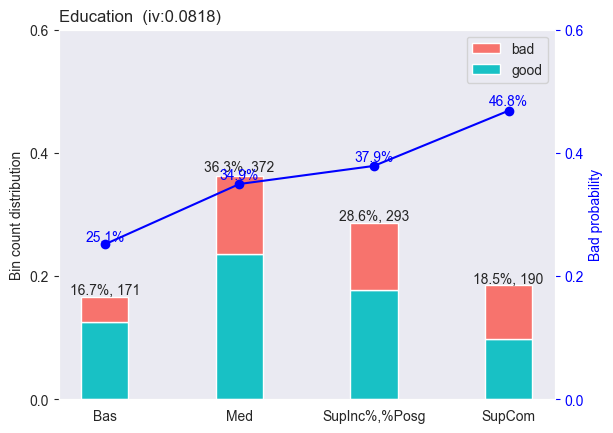

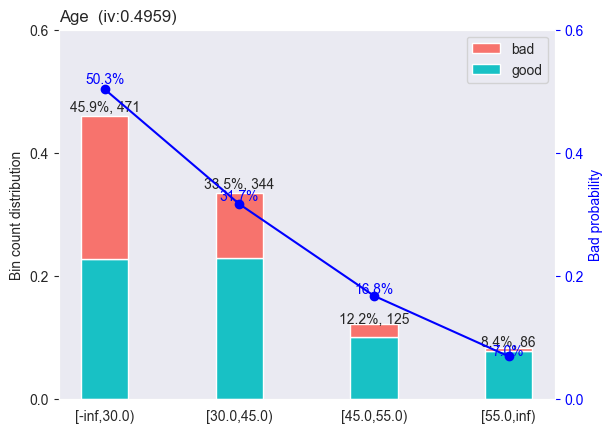

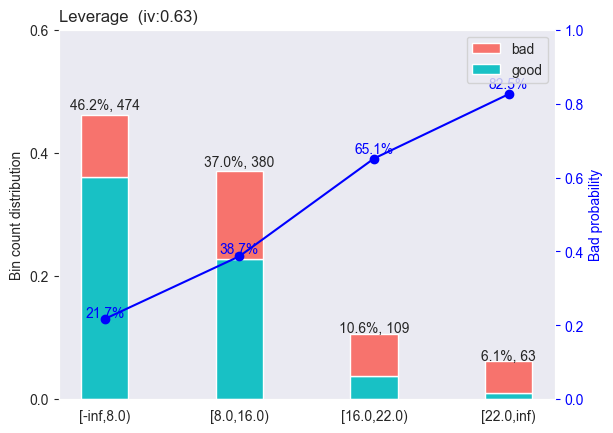

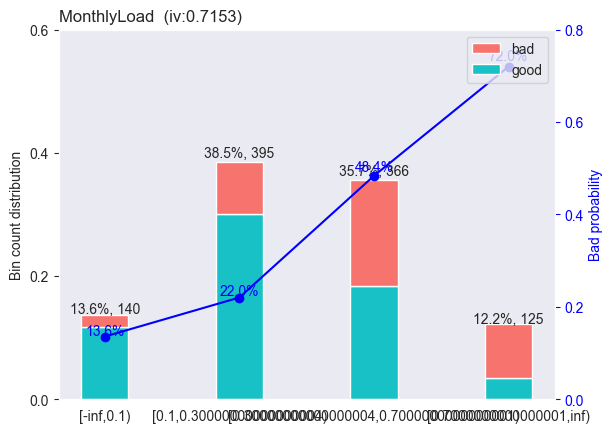

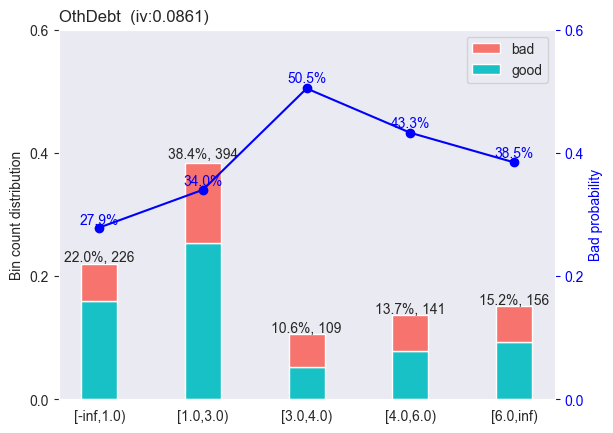

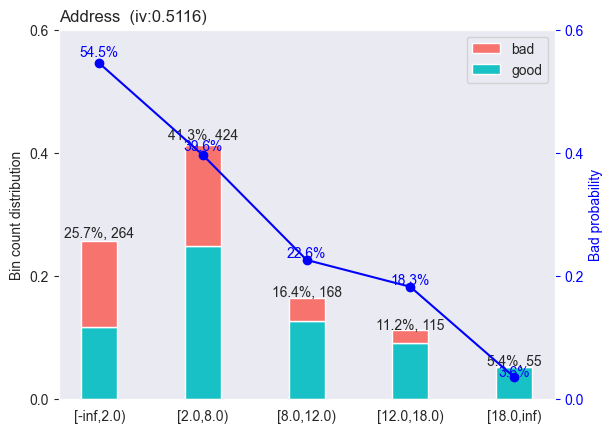

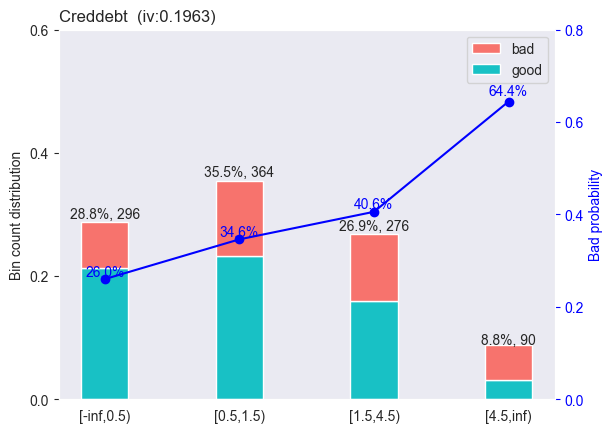

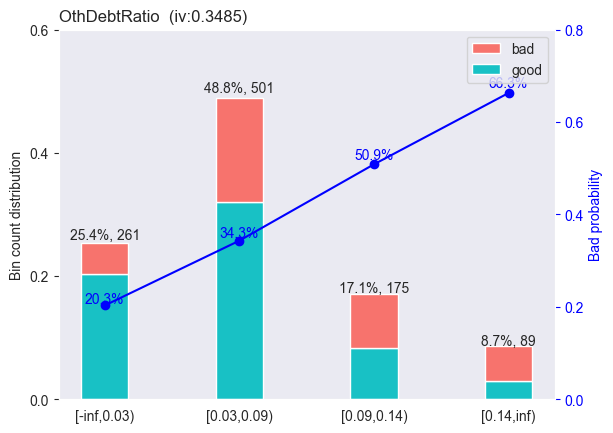

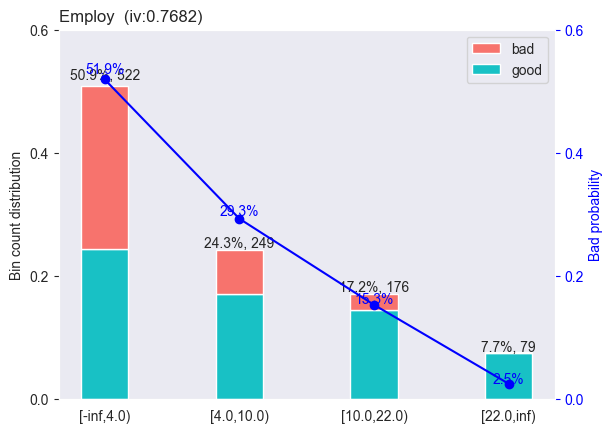

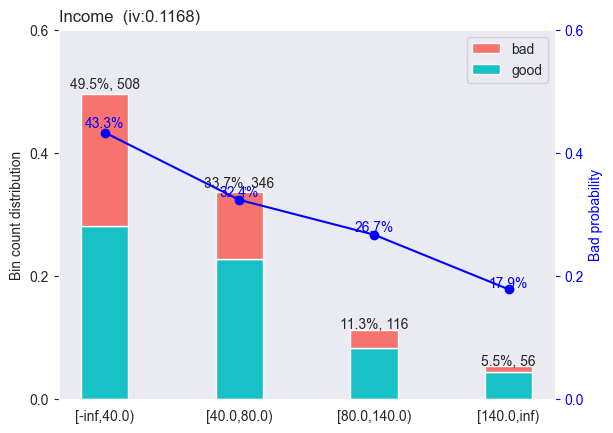

In [55]:
sc.woebin_plot(bins)

Si bien, los gráficos son útiles para analizar tendencias, a veces es mejor mirar los resultados de los cortes y la distribución de buenos y malos por cada corte.

In [56]:
bins

{'Education':     variable            bin  count  count_distr  good  bad   badprob  \
 0  Education            Bas    171     0.166667   128   43  0.251462   
 1  Education            Med    372     0.362573   242  130  0.349462   
 2  Education  SupInc%,%Posg    293     0.285575   182  111  0.378840   
 3  Education         SupCom    190     0.185185   101   89  0.468421   
 
         woe    bin_iv  total_iv         breaks  is_special_values  
 0 -0.530831  0.042858  0.081837            Bas              False  
 1 -0.061405  0.001355  0.081837            Med              False  
 2  0.065522  0.001237  0.081837  SupInc%,%Posg              False  
 3  0.433515  0.036387  0.081837         SupCom              False  ,
 'Age':   variable          bin  count  count_distr  good  bad   badprob       woe  \
 0      Age  [-inf,30.0)    471     0.459064   234  237  0.503185  0.572738   
 1      Age  [30.0,45.0)    344     0.335283   235  109  0.316860 -0.208239   
 2      Age  [45.0,55.0)    12

In [57]:
train_woe = sc.woebin_ply(train, bins) # Calcula WoE dataset de entrenamiento
test_woe  = sc.woebin_ply(test, bins) # Calcula WoE dataset de testeo

[INFO] converting into woe values ...
[INFO] converting into woe values ...


#### **3.2. Filtrando por Information Value (IV)**

Para filtrar en relación a éste criterio que mide el poder de predectibilidad de cada variable, se debe considerar la siguiente regla

- $IV < 0.02$: No tiene poder de predictibilidad, se remueve.
- $0.02 \le IV < 0.1$: Nivel débil de predictibilidad, se sugiere remover.
- $0.1 \le IV < 0.3$: Nivel de predectibilidad medio, mantener.
- $0.3 \le IV < 1$: Buen nivel de predectibilidad, mantener.
- $1 \le IV $: Nivel de predictibilidad demasiado bueno. Variable sospechosa. Se debe Estudiar si algún error en el cálculo (es decir, WoE deja una categoría con 100% de buenos o malos) o si la variable está capturando información futura. 

Para mostrar los resultados de los IV de las variables, podemos acceder a ella mediante la función `sc.iv()`

In [58]:
sc.iv(train_woe, 'Default')

,variable,info_value
1,Employ_woe,0.768201
8,MonthlyLoad_woe,0.715286
5,Leverage_woe,0.630021
7,Address_woe,0.511637
2,Age_woe,0.495903
6,OthDebtRatio_woe,0.348505
0,Creddebt_woe,0.196338
9,Income_woe,0.116779
4,OthDebt_woe,0.086080
3,Education_woe,0.081837


Como podemos ver que `Income`,`Education` y `OthDebt` y otras deudas están por debajo del umbral. `Education` y `OthDebt` son un poco extraños ya que tienen un IV muy cercano.

In [59]:
accepted_range = np.r_[0:10] 
train_woe = train_woe.iloc[:, accepted_range]
test_woe  = test_woe.iloc[:, accepted_range]
train_woe.head()

,Default,Education_woe,Age_woe,Leverage_woe,MonthlyLoad_woe,OthDebt_woe,Address_woe,Creddebt_woe,OthDebtRatio_woe,Employ_woe
0,0,-0.061405,0.572738,1.185092,0.494401,0.288846,0.138785,0.178631,0.594288,-0.320026
1,0,0.065522,-2.030268,0.099393,-0.704193,0.089995,-0.938774,1.154706,0.594288,-3.090660
2,0,-0.530831,-0.208239,-0.721474,-0.704193,-0.102843,-0.938774,-0.075990,-0.088565,-1.148111
3,0,-0.530831,-0.208239,2.113347,1.504460,0.089995,0.138785,0.178631,1.236339,-1.148111
4,1,-0.530831,0.572738,2.113347,1.504460,0.288846,0.138785,-0.075990,1.236339,0.636665


In [60]:
test_woe.head()

,Default,Education_woe,Age_woe,Leverage_woe,MonthlyLoad_woe,OthDebt_woe,Address_woe,Creddebt_woe,OthDebtRatio_woe,Employ_woe
14,0,-0.530831,-1.039870,0.099393,0.494401,0.578348,-0.938774,0.178631,-0.088565,-0.320026
20,1,-0.061405,0.572738,-0.721474,-0.704193,-0.102843,0.742320,0.178631,-0.088565,0.636665
22,0,0.065522,-1.039870,-0.721474,-0.704193,-0.102843,-0.669950,-0.485268,-0.088565,-0.320026
23,1,0.433515,-0.208239,0.099393,-0.704193,0.578348,-0.669950,1.154706,-0.088565,-1.148111
26,1,0.065522,-1.039870,0.099393,0.494401,0.089995,0.138785,0.178631,0.594288,0.636665


Guardando los resultados

In [61]:
train_woe.to_csv("data_process/train_woe.csv", index = False)
test_woe.to_csv("data_process/test_woe.csv", index = False)
pd.to_pickle(bankloan_data, 'BankloanCleanNewVars.pkl')

---
### **4. Regresión Logística y Scorecard**

In [62]:
bankloan_train_WoE = pd.read_csv('data_process/train_woe.csv')
bankloan_test_WoE  = pd.read_csv('data_process/test_woe.csv')
bankloan_data      = pd.read_pickle('BankloanCleanNewVars.pkl')

# Same train-test split as before (because of seed!)
bankloan_train_noWoE, bankloan_test_noWoE = sc.split_df(bankloan_data.iloc[:, 1:],
                                                        y = 'Default',
                                                        ratio = 0.7,
                                                        seed = 20211203).values()

# Nos damos nuevos breaks para los WoE
breaks_adj = {'Address': [1.0,2.0,8.0,17.0],
              'Age': [30.0,45.0,50.0],
              'Creddebt': [1.0, 6.0],
              'Employ': [4.0,14.0,22.0],
              'Income': [30.0,40.0,80.0,140.0],
              'Leverage': [8.0,16.0,22.0],
              'MonthlyLoad': [0.1,0.2,0.30000000000000004,0.7000000000000001],
              'OthDebt': [1.0,2.0,3.0],
              'OthDebtRatio': [0.1]
              }

# Aplico nuevos breaks.
bins_adj = sc.woebin(bankloan_train_noWoE, y="Default",
                     breaks_list = breaks_adj)

[INFO] creating woe binning ...


#### **4.1 Análisis de Correlación**

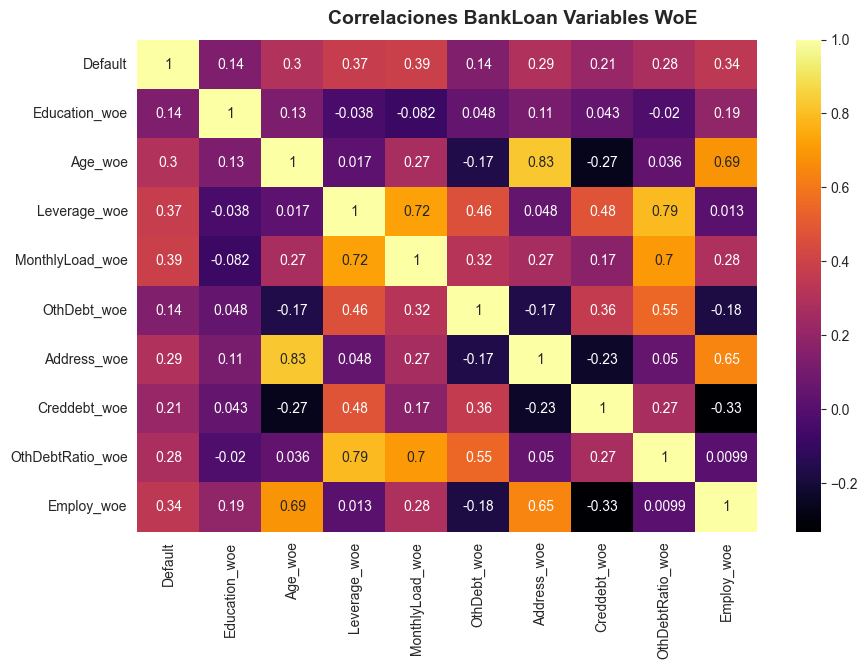

In [63]:
# Calculo la matriz de correlacion con las variables con WoE
fig, (ax) = plt.subplots(1, 1, figsize=(10,6))
corr = bankloan_train_WoE.corr()
sns.heatmap(corr,ax = ax,cmap ='inferno', annot=True)
fig.subplots_adjust(top = 0.93)
fig.suptitle('Correlaciones BankLoan Variables WoE', fontsize=14, fontweight='bold')
plt.show()

In [64]:
corr

,Default,Education_woe,Age_woe,Leverage_woe,MonthlyLoad_woe,OthDebt_woe,Address_woe,Creddebt_woe,OthDebtRatio_woe,Employ_woe
Default,1.000000,0.135644,0.300149,0.371372,0.391156,0.141368,0.293069,0.213750,0.279074,0.343521
Education_woe,0.135644,1.000000,0.125991,-0.037948,-0.082064,0.047930,0.112895,0.042935,-0.019900,0.191456
Age_woe,0.300149,0.125991,1.000000,0.017195,0.267504,-0.165523,0.825759,-0.267557,0.036263,0.686902
Leverage_woe,0.371372,-0.037948,0.017195,1.000000,0.720325,0.460625,0.047741,0.476233,0.787951,0.013230
MonthlyLoad_woe,0.391156,-0.082064,0.267504,0.720325,1.000000,0.315631,0.265906,0.168650,0.701794,0.282356
OthDebt_woe,0.141368,0.047930,-0.165523,0.460625,0.315631,1.000000,-0.165141,0.361668,0.548130,-0.180043
Address_woe,0.293069,0.112895,0.825759,0.047741,0.265906,-0.165141,1.000000,-0.234781,0.050029,0.645553
Creddebt_woe,0.213750,0.042935,-0.267557,0.476233,0.168650,0.361668,-0.234781,1.000000,0.267730,-0.331684
OthDebtRatio_woe,0.279074,-0.019900,0.036263,0.787951,0.701794,0.548130,0.050029,0.267730,1.000000,0.009897
Employ_woe,0.343521,0.191456,0.686902,0.013230,0.282356,-0.180043,0.645553,-0.331684,0.009897,1.000000


In [65]:
bankloan_logreg = LogisticRegressionCV(penalty='elasticnet', # Tipo de Penalizacion l1 = lasso, l2 = ridge, elasticnet
                                     Cs = 10,        # Cuántos parámetros probar. También puede ser un vector con parámetros para probar. 
                                     tol= 0.000001,  # Tolerancia paral a convergencia de los parametros
                                     cv = 3,         # Cuantos KFolds se haran. 3 o 5 es suficiente.
                                     fit_intercept = True, # Usara constante ?
                                     class_weight = 'balanced', # Ponderaciones
                                     random_state = 20211203, # Semilla aleatoria 
                                     max_iter = 100, # Numero maximo de iteraciones
                                     verbose = 0, # Muestra proceso. 1 si es si, 0 no
                                     solver = 'saga', # Como hara la optimizacion, el solver.
                                     n_jobs = 2,      # Procesadores a usar. Numero fisicos de core. 
                                     refit = True,     # Si volver a entrenar con el mejor parámetro y todos los datos después de terminar. .
                                     l1_ratios = np.arange(0, 1, 0.1), # Ratios para LASSO / Ridge 
                                    )

In [66]:
bankloan_logreg.fit(X = bankloan_train_WoE.iloc[:, 1:], 
                    y = bankloan_train_WoE['Default'])

,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.","array([0. , 0....7, 0.8, 0.9])"
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'elasticnet'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest sch

In [67]:
coef_df = pd.concat([pd.DataFrame({'column': bankloan_train_WoE.columns[1:]}), 
                    pd.DataFrame(np.transpose(bankloan_logreg.coef_))],
                    axis = 1
                   )

coef_df

,column,0
0,Education_woe,0.310313
1,Age_woe,0.296094
2,Leverage_woe,0.526016
3,MonthlyLoad_woe,0.292130
4,OthDebt_woe,0.145351
5,Address_woe,0.268139
6,Creddebt_woe,0.895238
7,OthDebtRatio_woe,0.070372
8,Employ_woe,0.803373


In [68]:
bankloan_logreg.intercept_

array([-0.00878509])

In [69]:
print(bankloan_logreg.l1_ratio_)
print(bankloan_logreg.C_)

[0.]
[0.04641589]


In [70]:
pred_class_test = bankloan_logreg.predict(bankloan_test_WoE.iloc[:, 1:])
probs_test = bankloan_logreg.predict_proba(bankloan_test_WoE.iloc[:, 1:])
print(probs_test[0:5], pred_class_test[0:5])

[[0.63547343 0.36452657]
 [0.39992379 0.60007621]
 [0.85494509 0.14505491]
 [0.51993578 0.48006422]
 [0.33987044 0.66012956]] [0 1 0 0 1]


confusion_matrix(y_true = bankloan_test_WoE['Default'], y_pred = pred_class_test)

#### **4.2 Scorecard**

Un scorecard es una tabla de puntos que traduce el output de la regresión logística en una escala numérica interpretable (ej. 300–850 puntos), donde mayor puntaje = menor riesgo de default.

**📌 ¿Cómo se calcula?** a partir del log-odds de la regresión logística, se aplica una transformación lineal:

\begin{equation*}
\text{Score} = A - B \cdot \left(\beta_0 + \sum_{j=1}^{p} \beta_j \cdot \text{WoE}_j \right)
\end{equation*}

donde $A$ y $B$ son constantes de calibración definidas por tres parámetros:

* `points0 = 750` Puntaje base en los odds de referencia
* `odds0 = 0.01`  Un cliente bueno, por cada 100 malos
* `pdo = 50` Puntos que duplican los odds 

Cada variable aporta puntos según su bin WoE, y la suma total es el score del cliente.

**📌 ¿Para qué sirve?**:

* Decisión de crédito: se define un umbral (ej. score < 600 hay que rechazar).
* Interpretabilidad regulatoria: cada variable explica cuántos puntos aporta o resta, cumpliendo exigencias de Basilea.
* Comunicación operacional: los ejecutivos de negocios entienden "700 puntos" mejor que "probabilidad 0.12".

In [71]:
# Extraccion de Parametros de la regresion logistica
best_C        = bankloan_logreg.C_[0]
best_l1_ratio = bankloan_logreg.l1_ratio_[0]

In [72]:
# Entrenar el modelo de regresion logistica con los mejores parametros
lr_scorecard = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    C=best_C,
    l1_ratio=best_l1_ratio,
    class_weight='balanced',
    fit_intercept=True,
    random_state=20211203,
    max_iter=1000
)

lr_scorecard.fit(bankloan_train_WoE.iloc[:, 1:], bankloan_train_WoE['Default'])

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'elasticnet'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",np.float64(0....5888336127774)
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",np.float64(0.0)
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",20211203
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably w

In [73]:
bankloan_sc = sc.scorecard(bins_adj,         # bins desde los WoE
                           lr_scorecard,  # Regresion logistica Entrenado anteriormente
                           bankloan_train_WoE.columns[1:], # Nombres de las variables de la LR entrenada
                           points0 = 750, # Puntos Bases
                           odds0 = 0.01, # Base odds malos:buenos
                           pdo = 50 )  

In [74]:
# Aplicando la Scorecard a las variables 
train_score = sc.scorecard_ply(bankloan_train_noWoE, bankloan_sc, print_step=0)
test_score  = sc.scorecard_ply(bankloan_test_noWoE, bankloan_sc,  print_step=0)

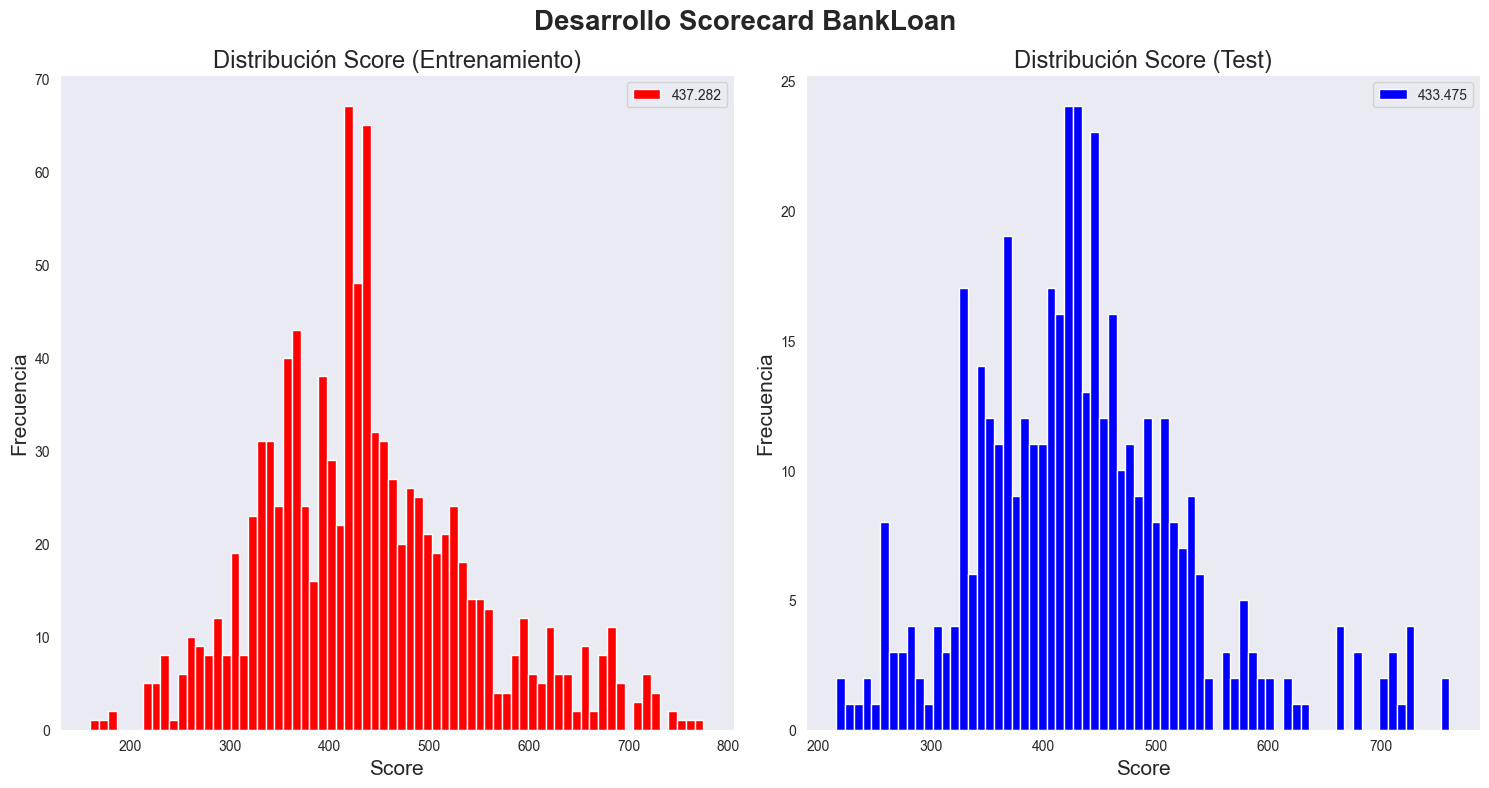

In [75]:
# Plots asociados a las Scorecard de Train y Test 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,8))
# Titulo
plt.suptitle("Desarrollo Scorecard BankLoan", fontsize = 20, fontweight='bold')
# Score para Entrenamiento
ax1.hist(train_score, bins=70, label=np.mean(train_score).round(3),color = "red", ec="skyblue")
ax1.set_xlabel("Score", fontsize = 15)
ax1.set_ylabel("Frecuencia", fontsize = 15)
ax1.set_title("Distribución Score (Entrenamiento)", fontsize=17)
ax1.legend(loc=1)
# Score para Test 
ax2.hist(test_score, bins=70, label=np.mean(test_score).round(3), color = "blue", ec="blue")
ax2.set_xlabel("Score", fontsize = 15)
ax2.set_ylabel("Frecuencia", fontsize = 15)
ax2.set_title("Distribución Score (Test)", fontsize=17)
ax2.legend(loc=1)
plt.tight_layout()
plt.show()